In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("Data_Train.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
def convert_duration(duration):
    h = 0
    m = 0
    if 'h' in duration:
        h = int(duration.split('h')[0])
    if 'm' in duration:
        m = int(duration.split('m')[-2].split()[-1])
    return h*60 + m

df["Duration_min"] = df["Duration"].apply(convert_duration)

In [10]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month

df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour

In [11]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop':0,
    '1 stop':1,
    '2 stops':2,
    '3 stops':3,
    '4 stops':4
})

In [36]:
df.groupby("Airline")["Price"].mean().sort_values(ascending=False)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11643.923357
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9612.427756
Vistara Premium economy               8962.333333
Vistara                               7796.348643
GoAir                                 5861.056701
IndiGo                                5673.682903
Air Asia                              5590.260188
SpiceJet                              4338.284841
Trujet                                4140.000000
Name: Price, dtype: float64

In [37]:
df.groupby(["Source", "Destination"])["Price"].mean().sort_values(ascending=False)

Source    Destination
Banglore  New Delhi      11917.716738
Delhi     Cochin         10540.113536
Kolkata   Banglore        9158.389411
Banglore  Delhi           5143.918577
Mumbai    Hyderabad       5059.708752
Chennai   Kolkata         4789.892388
Name: Price, dtype: float64

In [38]:
df.groupby("Total_Stops")["Price"].mean()

Total_Stops
0     5024.900315
1    10594.123556
2    12715.807895
3    13112.000000
4    17686.000000
Name: Price, dtype: float64

In [39]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['Month'] = df['Date_of_Journey'].dt.month

df.groupby("Month")["Price"].mean()

Month
3    10673.205580
4     5770.847081
5     9127.722944
6     8828.796134
Name: Price, dtype: float64

In [40]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df.groupby("Dep_Hour")["Price"].mean()

Dep_Hour
0      7615.075000
1      4354.621622
2      8419.974227
3     10474.625000
4      7251.876471
5      9681.992051
6      8314.480349
7      8496.111880
8     10083.322812
9      9644.166120
10     8927.750000
11     9290.025862
12     9251.573034
13     9064.052758
14     9906.034417
15     7687.410658
16    10320.459746
17     8736.929496
18    10035.824324
19     8484.821869
20     9670.574501
21     8455.717480
22     7858.405685
23     9473.770186
Name: Price, dtype: float64

In [42]:
df[['Duration_min', 'Price']].head()

,Duration_min,Price
0,170,3897
1,445,7662
2,1140,13882
3,325,6218
4,285,13302


In [43]:
df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [44]:
df.loc[df['Price'].idxmin()]
df.loc[df['Price'].idxmax()]

Airline            Jet Airways Business
Date_of_Journey     2019-03-01 00:00:00
Source                         Banglore
Destination                   New Delhi
Route                   BLR → BOM → DEL
Dep_Time                          05:45
Arrival_Time                      11:25
Duration                         5h 40m
Total_Stops                           1
Additional_Info          Business class
Price                             79512
Duration_min                        340
Journey_Day                           1
Journey_Month                         3
Dep_Hour                              5
Arrival_Hour                         11
Price_capped                      15764
Log_Price                     11.283676
Month                                 3
Name: 2924, dtype: object

In [17]:
neon_rainbow = [
    "#FF1E1E",  # Neon Red
    "#FF9F1C",  # Neon Orange
    "#FFF700",  # Neon Yellow
    "#39FF14",  # Neon Green
    "#00E5FF",  # Neon Cyan
    "#2979FF",  # Neon Blue
    "#B026FF"   # Neon Purple
]

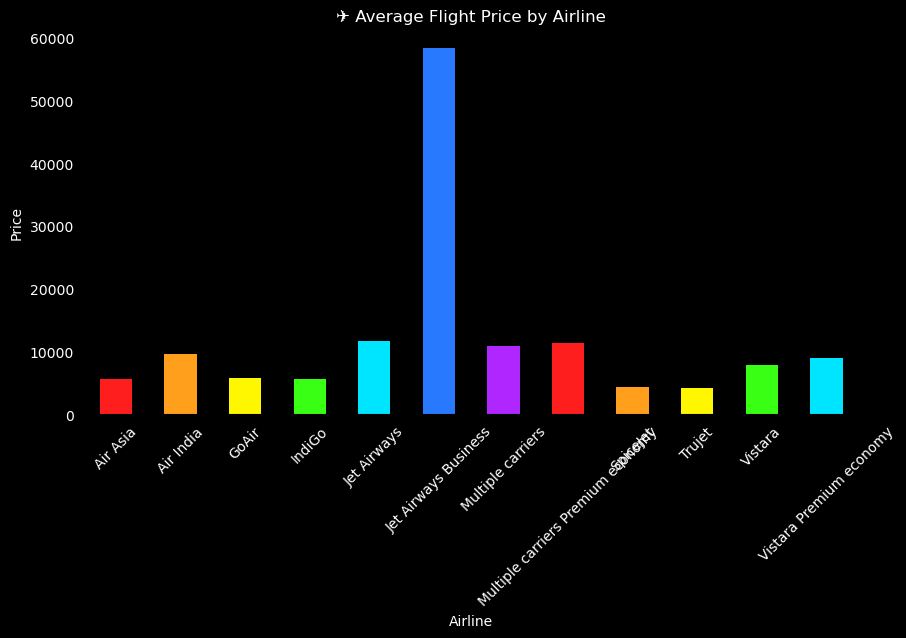

In [18]:
plt.figure(figsize=(10,5))

df.groupby("Airline")["Price"].mean().plot(
    kind="bar",
    color=neon_rainbow
)

plt.title("✈️ Average Flight Price by Airline", color="white")
plt.xlabel("Airline", color="white")
plt.ylabel("Price", color="white")

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("black")

plt.show()

In [21]:
lower = df['Price'].quantile(0.05)   # bottom 5%
upper = df['Price'].quantile(0.95)   # top 5%

df['Price_capped'] = df['Price'].clip(lower, upper)

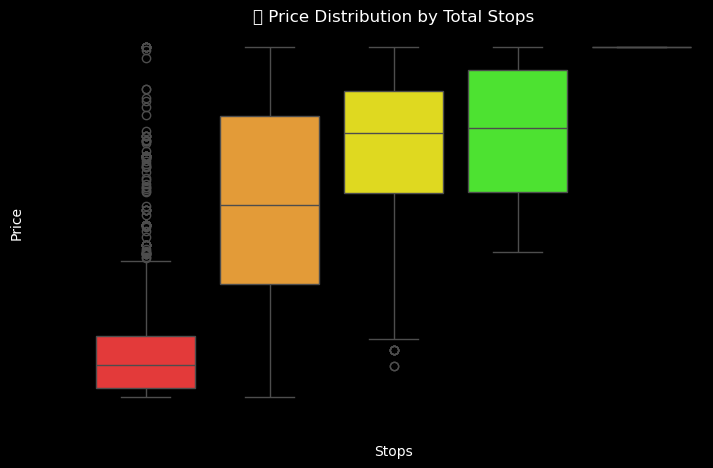

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Total_Stops",
    y='Price_capped',
    data=df,
    palette=neon_rainbow
)

plt.title("💡 Price Distribution by Total Stops", color="white")
plt.xlabel("Stops", color="white")
plt.ylabel("Price", color="white")

plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("black")

plt.show()

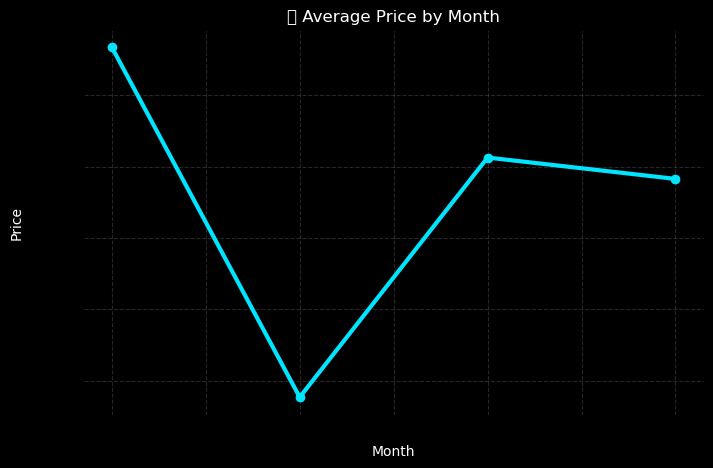

In [20]:
plt.figure(figsize=(8,5))

df.groupby("Journey_Month")["Price"].mean().plot(
    marker="o",
    linewidth=3,
    color="#00E5FF"
)

plt.title("📅 Average Price by Month", color="white")
plt.xlabel("Month", color="white")
plt.ylabel("Price", color="white")

plt.grid(color="gray", linestyle="--", alpha=0.3)

plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("black")

plt.show()

In [45]:
pivot = df.pivot_table(values="Price", index="Source", columns="Destination", aggfunc="mean")

<Axes: xlabel='Dep_Hour'>

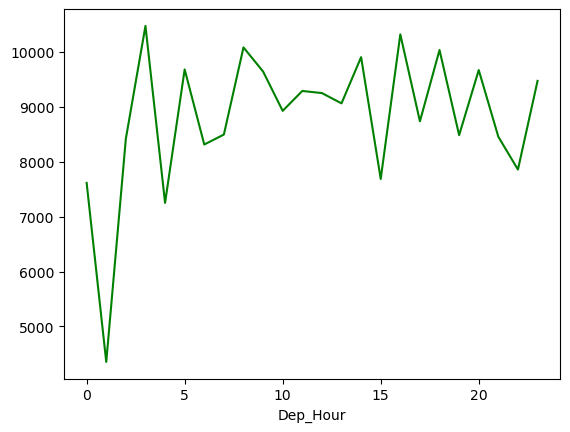

In [48]:
df.groupby("Dep_Hour")["Price"].mean().plot(kind="line",color='green')

In [50]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_min,Journey_Day,Journey_Month,Dep_Hour,Arrival_Hour,Price_capped,Log_Price,Month
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,170,24,3,22,1,3897,8.268219,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,445,1,5,5,13,7662,8.944159,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,1140,9,6,9,4,13882,9.538420,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,325,12,5,18,23,6218,8.735364,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,285,1,3,16,21,13302,9.495745,3
